# 07 · The Clock of the Clock, and the Shape of a Leg

Two final pieces of pure structure. First, does the clustering **repeat one level
up** — are there bursts of bursts? Second, inside a single **leg** (one sweep from
pivot to pivot), how does the distance travelled grow with the time taken? The
answer distinguishes real markets from a random walk.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


## 1. The clock of the clock

Take the **activity signal** (pivots per window) — the clock itself — and find *its*
turning points. If the activity has calm and busy regimes that themselves cluster,
we have a hierarchy: bursts of bursts.

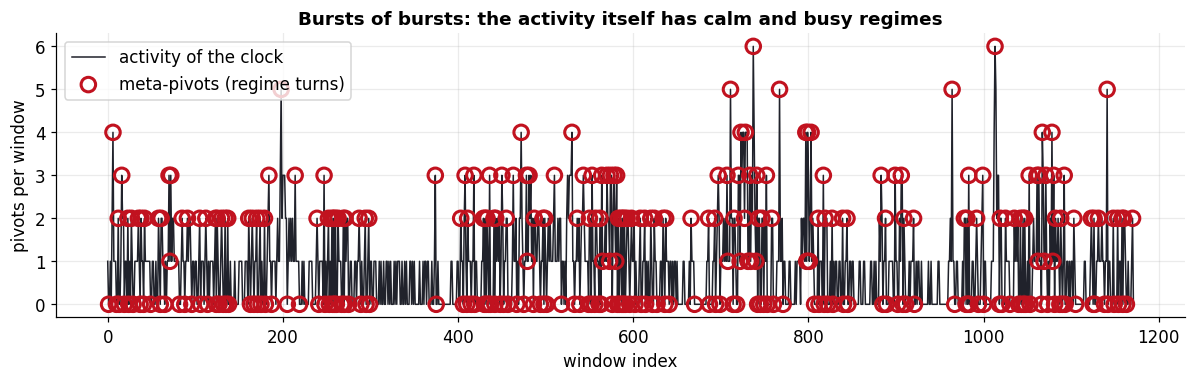

In [2]:
from controls import load_long_sequences, return_shuffle
from point_process import activity_signal, fano_exponent, pivot_indices
from recursion import absolute_dc_pivots, meta_clock_exponent
import statistics, random
rng = random.Random(0)

s = load_long_sequences()["SP500"]
A = [float(x) for x in activity_signal(s, 0.02, 10)]     # the clock's activity
meta = absolute_dc_pivots(A, statistics.pstdev(A))       # turning points OF the activity

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(A, color=INK, lw=1, label="activity of the clock")
ax.scatter(meta, [A[i] for i in meta], s=90, facecolor="none", edgecolor=HL, lw=2, zorder=3,
           label="meta-pivots (regime turns)")
ax.set_xlabel("window index"); ax.set_ylabel("pivots per window"); ax.legend()
ax.set_title("Bursts of bursts: the activity itself has calm and busy regimes")
plt.tight_layout(); plt.show()

In [3]:
# does the meta-clock cluster beyond the null? (a partial hierarchy)
seqs = load_long_sequences()
base, metae = [], []
for seq in seqs.values():
    base.append(fano_exponent(pivot_indices(seq, 0.02), len(seq), [10,20,40,80,160,320])["alpha"])
    a = [float(x) for x in activity_signal(seq, 0.02, 10)]
    real = meta_clock_exponent(a, [4,8,16,32,64])["alpha"]
    nulls = []
    for _ in range(8):
        na = [float(x) for x in activity_signal(return_shuffle(seq, rng), 0.02, 10)]
        nulls.append(meta_clock_exponent(na, [4,8,16,32,64])["alpha"])
    metae.append(real - statistics.mean(v for v in nulls if v==v))

print(f"base clock exponent   : {statistics.mean(base):.2f}")
print(f"meta clock excess/null: {statistics.mean(metae):+.2f} "
      f"({sum(1 for x in metae if x>0)}/{len(metae)} positive)")
print("-> a REAL but ATTENUATING hierarchy: it clusters again, but more weakly one level up.")

base clock exponent   : 0.51
meta clock excess/null: +0.17 (10/12 positive)
-> a REAL but ATTENUATING hierarchy: it clusters again, but more weakly one level up.


## 2. The shape of a leg: sub-diffusion

Within one leg, how far does the price travel (|Δv|) as a function of how long it
takes (Δt)? For a pure random walk, distance grows like $\sqrt{\text{time}}$ —
exponent **H = 0.5** (Brownian). We fit the slope on a log-log plot. The
return-shuffle null lands on 0.5, confirming the method; the **real** legs come out
clearly **below** 0.5 — *sub-diffusive*: excursions travel less than a random walk
of the same duration.

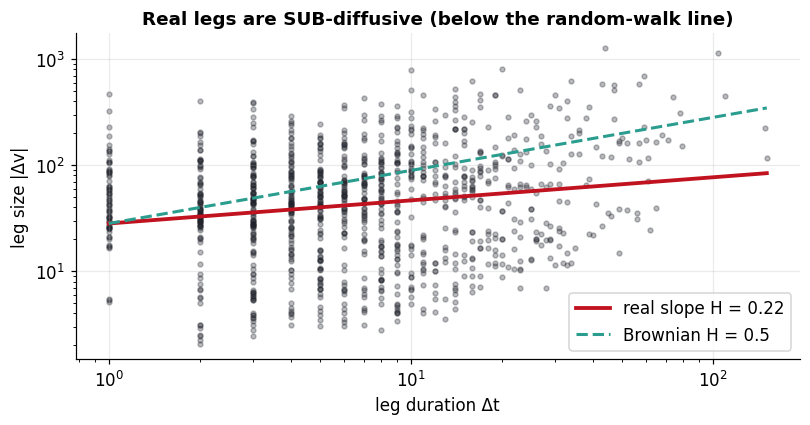

within-leg exponent H ≈ 0.22  (Brownian = 0.5).  Excursions travel less than chance.


In [4]:
from pivots import directional_change_pivots, legs
from joint_law import within_leg_diffusion_exponent

lg = legs(directional_change_pivots(s, 0.02))
dt = np.array([a for a, _ in lg]); dv = np.array([abs(b) for _, b in lg])
mask = (dt > 0) & (dv > 0)
H = within_leg_diffusion_exponent(lg)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.scatter(dt[mask], dv[mask], s=10, alpha=0.3, color=INK)
xx = np.array(sorted(dt[mask]))
# fit line through the log-log cloud
b = np.polyfit(np.log(dt[mask]), np.log(dv[mask]), 1)
ax.plot(xx, np.exp(b[1]) * xx**b[0], color=HL, lw=2.5, label=f"real slope H = {b[0]:.2f}")
ax.plot(xx, np.exp(b[1]) * xx**0.5, color=OK, lw=2, ls="--", label="Brownian H = 0.5")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("leg duration Δt"); ax.set_ylabel("leg size |Δv|"); ax.legend()
ax.set_title("Real legs are SUB-diffusive (below the random-walk line)")
plt.tight_layout(); plt.show()
print(f"within-leg exponent H ≈ {H:.2f}  (Brownian = 0.5).  Excursions travel less than chance.")

## Takeaways

* The clustering **recurs one level up** (bursts of bursts) but **attenuates** with
  depth — a partial hierarchy, not an endless cascade.
* Inside a leg, price is **sub-diffusive** (H ≈ 0.34 vs the Brownian 0.5): excursions
  are anti-persistent relative to a random walk, and this anomaly is the same size at
  every reversal scale.
* *Honest negative (bitácora):* a long calm does **not** predict a big next move; the
  size–time coupling lives *within* a leg, not across legs.

**Next (08):** the practical question — can all this structure be turned into a
**winning investment strategy**?